In [2]:
import gc
import os
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm import tqdm

# Prevent CUDA memory fragmentation
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# Preserve device context patch preventing accidental meta-device loading
import torch.utils._device

if not getattr(torch.utils._device.DeviceContext.__init__, "_is_patched", False):
    _original_device_context_init = torch.utils._device.DeviceContext.__init__

    def _patched_device_context_init(self, device, *args, **kwargs):
        if str(device) == "meta":
            device = torch.device("cpu")
        _original_device_context_init(self, device, *args, **kwargs)

    _patched_device_context_init._is_patched = True
    torch.utils._device.DeviceContext.__init__ = _patched_device_context_init

if hasattr(torch, "set_default_device") and not getattr(
    torch.set_default_device, "_is_patched", False
):
    _original_set_default_device = torch.set_default_device

    def _patched_set_default_device(device):
        if str(device) == "meta":
            device = "cpu"
        _original_set_default_device(device)

    _patched_set_default_device._is_patched = True
    torch.set_default_device = _patched_set_default_device

from transformers import (
    AutoConfig,
    AutoModelForCausalLM,
    AutoModelForMaskedLM,
    AutoTokenizer,
)

MAX_SEQUENCE_LENGTH = 4096
WINDOW_STRIDE = 512

/blue/salemi/simonerancati/.conda/envs/embeddings/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def clear_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.reset_peak_memory_stats()
        except Exception:
            pass
    gc.collect()


def max_pool_logits_without_padding_mask(logits: torch.Tensor) -> torch.Tensor:
    if logits.ndim != 3:
        raise ValueError(f"Expected 3D logits tensor, got shape {tuple(logits.shape)}.")
    return torch.max(logits, dim=1).values


def mean_pool_logits_without_padding_mask(logits: torch.Tensor) -> torch.Tensor:
    if logits.ndim != 3:
        raise ValueError(f"Expected 3D logits tensor, got shape {tuple(logits.shape)}.")
    return torch.mean(logits, dim=1)


def extract_logits(model_output: Any) -> torch.Tensor:
    if hasattr(model_output, "logits") and model_output.logits is not None:
        return model_output.logits
    if isinstance(model_output, (tuple, list)) and len(model_output) > 0:
        return model_output[0]
    raise TypeError(f"Could not extract logits from {type(model_output).__name__}.")


def resolve_vir2vec_repository(model_name: str) -> Tuple[str, Optional[str]]:
    repo_id = model_name
    revision = None
    if "pabloarozarenad/vir2vec-" in model_name.lower():
        size_suffix = model_name.split("-")[-1]
        repo_id = "pabloarozarenad/Vir2vec"
        if size_suffix in {"17M", "138M"}:
            revision = size_suffix
    return repo_id, revision


def model_head_type(model_name: str) -> str:
    name = model_name.lower()
    if "modernbert" in name or "dnabert" in name:
        return "masked_lm"
    if "mistral-dna" in name or "vir2vec" in name:
        return "causal_lm"
    raise ValueError(f"No LM head mapping defined for {model_name!r}.")


def verify_language_model_head_loading(model_name: str, missing_keys: Sequence[str]):
    head_markers = ("lm_head", "cls.predictions", "predictions.decoder", "decoder.weight", "decoder.bias", "unembed")
    missing_head_keys = [k for k in missing_keys if any(m in k.lower() for m in head_markers)]
    if missing_head_keys:
        raise RuntimeError(f"{model_name} missing pretrained LM head keys: {missing_head_keys}")


def load_huggingface_lm(model_name: str, device: torch.device):
    repo_id, revision = resolve_vir2vec_repository(model_name)
    head_type = model_head_type(model_name)
    token = os.environ.get("HF_TOKEN")

    tokenizer = AutoTokenizer.from_pretrained(
        repo_id, 
        revision=revision, 
        trust_remote_code=True,
        token=token
    )
    tokenizer.padding_side = "left"

    if tokenizer.pad_token_id is None:
        if tokenizer.eos_token_id is not None:
            tokenizer.pad_token = tokenizer.eos_token
        elif tokenizer.unk_token_id is not None:
            tokenizer.pad_token = tokenizer.unk_token
        else:
            raise ValueError(f"Tokenizer for {model_name} has no usable pad token.")

    config = AutoConfig.from_pretrained(
        repo_id, 
        revision=revision, 
        trust_remote_code=True,
        token=token
    )
    config.pad_token_id = tokenizer.pad_token_id
    if hasattr(config, "use_cache"):
        config.use_cache = False

    if hasattr(config, "sliding_window"):
        config.sliding_window = None

    model_class = AutoModelForCausalLM if head_type == "causal_lm" else AutoModelForMaskedLM
    model, loading_info = model_class.from_pretrained(
        repo_id,
        revision=revision,
        config=config,
        trust_remote_code=True,
        torch_dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float32,
        attn_implementation="eager",
        low_cpu_mem_usage=False,
        output_loading_info=True,
        token=token
    )

    verify_language_model_head_loading(model_name, missing_keys=loading_info.get("missing_keys", []))
    model = model.to(device)
    model.eval()
    return tokenizer, model, head_type

In [4]:
# HIV-1 HXB2 Reference Sequence (NC_001802.1 / K03455.1)
HIV1_HXB2_SEQ = (
    "TGGAAGGGCTAATTCACTCCCAACGAAGACAAGATATCCTTGATCTGTGGATCTACCACACACAAGGCTA"
    "CTTCCCTGATTAGCAGAACTACACACCAGGGCCAGGGATCAGATATCCACTGACCTTTGGATGGTGCTAC"
    "AAGCTAGTACCAGTTGAGCCAGAGAAGTTAGAAGAAGCCAACAAAGGAGAGAACACCAGCTTGTTACACC"
    "CTGTGAGCCTGCATGGAATGGATGACCCGGAGAGAGAAGTGTTAGAGTGGAGGTTTGACAGCCGCCTAGC"
    "ATTTCATCACATGGCCCGAGAGCTGCATCCGGAGTACTTCAAGAACTGCTGACATCGAGCTTGCTACAAG"
    "GGACTTTCCGCTGGGGACTTTCCAGGGAGGCGTGGCCTGGGCGGGACTGGGGAGTGGCGAGCCCTCAGAT"
    "CCTGCATATAAGCAGCTGCTTTTTGCCTGTACTGGGTCTCTCTGGTTAGACCAGATCTGAGCCTGGGAGC"
    "TCTCTGGCTAACTAGGGAACCCACTGCTTAAGCCTCAATAAAGCTTGCCTTGAGTGCTTCAAGTAGTGTG"
    "TGCCCGTCTGTTGTGTGACTCTGGTAACTAGAGATCCCTCAGACCCTTTTAGTCAGTGTGGAAAATCTCT"
    "AGCAGTGGCGCCCGAACAGGGACCTGAAAGCGAAAGGGAAACCAGAGGAGCTCTCTCGACGCAGGACTCG"
    "GCTTGCTGAAGCGCGCACGGCAAGAGGCGAGGGGCGGCGACTGGTGAGTACGCCAAAAATTTTGACTAGC"
    "GGAGGCTAGAAGGAGAGAGATGGGTGCGAGAGCGTCAGTATTAAGCGGGGGAGAATTAGATCGATGGGAA"
    "AAAATTCGGTTAAGGCCAGGGGGAAAGAAAAAATATAAATTAAAACATATAGTATGGGCAAGCAGGGAGC"
    "TAGAACGATTCGCAGTTAATCCTGGCCTGTTAGAAACATCAGAAGGCTGTAGACAAATACTGGGACAGCT"
    "ACAACCATCCCTTCAGACAGGATCAGAAGAACTTAGATCATTATATAATACAGTAGCAACCCTCTATTGT"
    "GTGCATCAAAGGATAGAGATAAAAGACACCAAGGAAGCTTTAGACAAGATAGAGGAAGAGCAAAACAAAA"
    "GTAAGAAAAAAGCACAGCAAGCAGCAGCTGACACAGGACACAGCAATCAGGTCAGCCAAAATTACCCTAT"
    "AGTGCAGAACATCCAGGGGCAAATGGTACATCAGGCCATATCACCTAGAACTTTAAATGCATGGGTAAAA"
    "GTAGTAGAAGAGAAGGCTTTCAGCCCAGAAGTGATACCCATGTTTTCAGCATTATCAGAAGGAGCCACCC"
    "CACAAGATTTAAACACCATGCTAAACACAGTGGGGGGACATCAAGCAGCCATGCAAATGTTAAAAGAGAC"
    "CATCAATGAGGAAGCTGCAGAATGGGATAGAGTGCATCCAGTGCATGCAGGGCCTATTGCACCAGGCCAG"
    "ATGAGAGAACCAAGGGGAAGTGACATAGCAGGAACTACTAGTACCCTTCAGGAACAAATAGGATGGATGA"
    "CAAATAATCCACCTATCCCAGTAGGAGAAATTTATAAAAGATGGATAATCCTGGGATTAAATAAAATAGT"
    "AAGAATGTATAGCCCTACCAGCATTCTGGACATAAGACAAGGACCAAAGGAACCCTTTAGAGACTATGTA"
    "GACCGGTTCTATAAAACTCTAAGAGCCGAGCAAGCTTCACAGGAGGTAAAAAATTGGATGACAGAAACCT"
    "TGTTGGTCCAAAATGCGAACCCAGATTGTAAGACTATTTTAAAAGCATTGGGACCAGCGGCTACACTAGA"
    "AGAAATGATGACAGCATGTCAGGGAGTAGGAGGACCCGGCCATAAGGCAAGAGTTTTGGCTGAAGCAATG"
    "AGCCAAGTAACAAATTCAGCTACCATAATGATGCAGAGAGGCAATTTTAGGAACCAAAGAAAGATTGTTA"
    "AGTGTTTCAATTGTGGCAAAGAAGGGCACACAGCCAGAAATTGCAGGGCCCCTAGGAAAAAGGGCTGTTG"
    "GAAATGTGGAAAGGAAGGACACCAAATGAAAGATTGTACTGAGAGACAGGCTAATTTTTTAGGGAAGATC"
    "TGGCCTTCCTACAAGGGAAGGCCAGGGAATTTTCTTCAGAGCAGACCAGAGCCAACAGCCCCACCAGAAG"
    "AGAGCTTCAGGTCTGGGGTAGAGACAACAACTCCCCCTCAGAAGCAGGAGCCGATAGACAAGGAACTGTA"
    "TCCTTTAACTTCCCTCAGGTCACTCTTTGGCAACGACCCCTCGTCACAATAAAGATAGGGGGGCAACTAA"
    "AGGAAGCTCTATTAGATACAGGAGCAGATGATACAGTATTAGAAGAAATGAGTTTGCCAGGAAGATGGAA"
    "ACCAAAAATGATAGGGGGAATTGGAGGTTTTATCAAAGTAAGACAGTATGATCAGATACTCATAGAAATC"
    "TGTGGACATAAAGCTATAGGTACAGTATTAGTAGGACCTACACCTGTCAACATAATTGGAAGAAATCTGT"
    "TGACTCAGATTGGTTGCACTTTAAATTTTCCCATTAGCCCTATTGAGACTGTACCAGTAAAATTAAAGCC"
    "AGGAATGGATGGCCCAAAAGTTAAACAATGGCCATTGACAGAAGAAAAAATAAAAGCATTAGTAGAAATT"
    "TGTACAGAGATGGAAAAGGAAGGGAAAATTTCAAAAATTGGGCCTGAAAATCCATACAATACTCCAGTAT"
    "TTGCCATAAAGAAAAAAGACAGTACTAAATGGAGAAAATTAGTAGATTTCAGAGAACTTAATAAGAGAAC"
    "TCAAGACTTCTGGGAAGTTCAATTAGGAATACCACATCCCGCAGGGTTAAAAAAGAAAAAATCAGTAACA"
    "GTACTGGATGTGGGTGATGCATATTTTTCAGTTCCCTTAGATGAAGACTTCAGGAAGTATACTGCATTTA"
    "CCATACCTAGTATAAACAATGAGACACCAGGGATTAGATATCAGTACAATGTGCTTCCACAGGGATGGAA"
    "AGGATCACCAGCAATATTCCAAAGTAGCATGACAAAAATCTTAGAGCCTTTTAGAAAACAAAATCCAGAC"
    "ATAGTTATCTATCAATACATGGATGATTTGTATGTAGGATCTGACTTAGAAATAGGGCAGCATAGAACAA"
    "AAATAGAGGAGCTGAGACAACATCTGTTGAGGTGGGGACTTACCACACCAGACAAAAAACATCAGAAAGA"
    "ACCTCCATTCCTTTGGATGGGTTATGAACTCCATCCTGATAAATGGACAGTACAGCCTATAGTGCTGCCA"
    "GAAAAAGACAGCTGGACTGTCAATGACATACAGAAGTTAGTGGGGAAATTGAATTGGGCAAGTCAGATTT"
    "ACCCAGGGATTAAAGTAAGGCAATTATGTAAACTCCTTAGAGGAACCAAAGCACTAACAGAAGTAATACC"
    "ACTAACAGAAGAAGCAGAGCTAGAACTGGCAGAAAACAGAGAGATTCTAAAAGAACCAGTACATGGAGTG"
    "TATTATGACCCATCAAAAGACTTAATAGCAGAAATACAGAAGCAGGGGCAAGGCCAATGGACATATCAAA"
    "TTTATCAAGAGCCATTTAAAAATCTGAAAACAGGAAAATATGCAAGAATGAGGGGTGCCCACACTAATGA"
    "TGTAAAACAATTAACAGAGGCAGTGCAAAAAATAACCACAGAAAGCATAGTAATATGGGGAAAGACTCCT"
    "AAATTTAAACTGCCCATACAAAAGGAAACATGGGAAACATGGTGGACAGAGTATTGGCAAGCCACCTGGA"
    "TTCCTGAGTGGGAGTTTGTTAATACCCCTCCCTTAGTGAAATTATGGTACCAGTTAGAGAAAGAACCCAT"
    "AGTAGGAGCAGAAACCTTCTATGTAGATGGGGCAGCTAACAGGGAGACTAAATTAGGAAAAGCAGGATAT"
    "GTTACTAATAGAGGAAGACAAAAAGTTGTCACCCTAACTGACACAACAAATCAGAAGACTGAGTTACAAG"
    "CAATTTATCTAGCTTTGCAGGATTCGGGATTAGAAGTAAACATAGTAACAGACTCACAATATGCATTAGG"
    "AATCATTCAAGCACAACCAGATCAAAGTGAATCAGAGTTAGTCAATCAAATAATAGAGCAGTTAATAAAA"
    "AAGGAAAAGGTCTATCTGGCATGGGTACCAGCACACAAAGGAATTGGAGGAAATGAACAAGTAGATAAAT"
    "TAGTCAGTGCTGGAATCAGGAAAGTACTATTTTTAGATGGAATAGATAAGGCCCAAGATGAACATGAGAA"
    "ATATCACAGTAATTGGAGAGCAATGGCTAGTGATTTTAACCTGCCACCTGTAGTAGCAAAAGAAATAGTA"
    "GCCAGCTGTGATAAATGTCAGCTAAAAGGAGAAGCCATGCATGGACAAGTAGACTGTAGTCCAGGAATAT"
    "GGCAACTAGATTGTACACATTTAGAAGGAAAAGTTATCCTGGTAGCAGTTCATGTAGCCAGTGGATATAT"
    "AGAAGCAGAAGTTATTCCAGCAGAAACAGGGCAGGAAACAGCATATTTTCTTTTAAAATTAGCAGGAAGA"
    "TGGCCAGTAAAAACAATACATACTGACAATGGCAGCAATTTCACCGGTGCTACGGTTAGGGCCGCCTGTT"
    "GGTGGGCGGGAATCAAGCAGGAATTTGGAATTCCCTACAATCCCCAAAGTCAAGGAGTAGTAGAATCTAT"
    "GAATAAAGAATTAAAGAAAATTATAGGACAGGTAAGAGATCAGGCTGAACATCTTAAGACAGCAGTACAA"
    "ATGGCAGTATTCATCCACAATTTTAAAAGAAAAGGGGGGATTGGGGGGTACAGTGCAGGGGAAAGAATAG"
    "TAGACATAATAGCAACAGACATACAAACTAAAGAATTACAAAAACAAATTACAAAAATTCAAAATTTTCG"
    "GGTTTATTACAGGGACAGCAGAAATCCACTTTGGAAAGGACCAGCAAAGCTCCTCTGGAAAGGTGAAGGG"
    "GCAGTAGTAATACAAGATAATAGTGACATAAAAGTAGTGCCAAGAAGAAAAGCAAAGATCATTAGGGATT"
    "ATGGAAAACAGATGGCAGGTGATGATTGTGTGGCAAGTAGACAGGATGAGGATTAGAACATGGAAAAGTT"
    "TAGTAAAACACCATATGTATGTTTCAGGGAAAGCTAGGGGATGGTTTTATAGACATCACTATGAAAGCCC"
    "TCATCCAAGAATAAGTTCAGAAGTACACATCCCACTAGGGGATGCTAGATTGGTAATAACAACATATTGG"
    "GGTCTGCATACAGGAGAAAGAGACTGGCATTTGGGTCAGGGAGTCTCCATAGAATGGAGGAAAAAGAGAT"
    "ATAGCACACAAGTAGACCCTGAACTAGCAGACCAACTAATTCATCTGTATTACTTTGACTGTTTTTCAGA"
    "CTCTGCTATAAGAAAGGCCTTATTAGGACACATAGTTAGCCCTAGGTGTGAATATCAAGCAGGACATAAC"
    "AAGGTAGGATCTCTACAATACTTGGCACTAGCAGCATTAATAACACCAAAAAAGATAAAGCCACCTTTGC"
    "CTAGTGTTACGAAACTGACAGAGGATAGATGGAACAAGCCCCAGAAGACCAAGGGCCACAGAGGGAGCCA"
    "CACAATGAATGGACACTAGAGCTTTTAGAGGAGCTTAAGAATGAAGCTGTTAGACATTTTCCTAGGATTT"
    "GGCTCCATGGCTTAGGGCAACATATCTATGAAACTTATGGGGATACTTGGGCAGGAGTGGAAGCCATAAT"
    "AAGAATTCTGCAACAACTGCTGTTTATCCATTTTCAGAATTGGGTGTCGACATAGCAGAATAGGCGTTAC"
    "TCGACAGAGGAGAGCAAGAAATGGAGCCAGTAGATCCTAGACTAGAGCCCTGGAAGCATCCAGGAAGTCA"
    "GCCTAAAACTGCTTGTACCAATTGCTATTGTAAAAAGTGTTGCTTTCATTGCCAAGTTTGTTTCATAACA"
    "AAAGCCTTAGGCATCTCCTATGGCAGGAAGAAGCGGAGACAGCGACGAAGAGCTCATCAGAACAGTCAGA"
    "CTCATCAAGCTTCTCTATCAAAGCAGTAAGTAGTACATGTAACGCAACCTATACCAATAGTAGCAATAGT"
    "AGCATTAGTAGTAGCAATAATAATAGCAATAGTTGTGTGGTCCATAGTAATCATAGAATATAGGAAAATA"
    "TTAAGACAAAGAAAAATAGACAGGTTAATTGATAGACTAATAGAAAGAGCAGAAGACAGTGGCAATGAGA"
    "GTGAAGGAGAAATATCAGCACTTGTGGAGATGGGGGTGGAGATGGGGCACCATGCTCCTTGGGATGTTGA"
    "TGATCTGTAGTGCTACAGAAAAATTGTGGGTCACAGTCTATTATGGGGTACCTGTGTGGAAGGAAGCAAC"
    "CACCACTCTATTTTGTGCATCAGATGCTAAAGCATATGATACAGAGGTACATAATGTTTGGGCCACACAT"
    "GCCTGTGTACCCACAGACCCCAACCCACAAGAAGTAGTATTGGTAAATGTGACAGAAAATTTTAACATGT"
    "GGAAAAATGACATGGTAGAACAGATGCATGAGGATATAATCAGTTTATGGGATCAAAGCCTAAAGCCATG"
    "TGTAAAATTAACCCCACTCTGTGTTAGTTTAAAGTGCACTGATTTGAAGAATGATACTAATACCAATAGT"
    "AGTAGCGGGAGAATGATAATGGAGAAAGGAGAGATAAAAAACTGCTCTTTCAATATCAGCACAAGCATAA"
    "GAGGTAAGGTGCAGAAAGAATATGCATTTTTTTATAAACTTGATATAATACCAATAGATAATGATACTAC"
    "CAGCTATAAGTTGACAAGTTGTAACACCTCAGTCATTACACAGGCCTGTCCAAAGGTATCCTTTGAGCCA"
    "ATTCCCATACATTATTGTGCCCCGGCTGGTTTTGCGATTCTAAAATGTAATAATAAGACGTTCAATGGAA"
    "CAGGACCATGTACAAATGTCAGCACAGTACAATGTACACATGGAATTAGGCCAGTAGTATCAACTCAACT"
    "GCTGTTAAATGGCAGTCTAGCAGAAGAAGAGGTAGTAATTAGATCTGTCAATTTCACGGACAATGCTAAA"
    "ACCATAATAGTACAGCTGAACACATCTGTAGAAATTAATTGTACAAGACCCAACAACAATACAAGAAAAA"
    "GAATCCGTATCCAGAGAGGACCAGGGAGAGCATTTGTTACAATAGGAAAAATAGGAAATATGAGACAAGC"
    "ACATTGTAACATTAGTAGAGCAAAATGGAATAACACTTTAAAACAGATAGCTAGCAAATTAAGAGAACAA"
    "TTTGGAAATAATAAAACAATAATCTTTAAGCAATCCTCAGGAGGGGACCCAGAAATTGTAACGCACAGTT"
    "TTAATTGTGGAGGGGAATTTTTCTACTGTAATTCAACACAACTGTTTAATAGTACTTGGTTTAATAGTAC"
    "TTGGAGTACTGAAGGGTCAAATAACACTGAAGGAAGTGACACAATCACCCTCCCATGCAGAATAAAACAA"
    "ATTATAAACATGTGGCAGAAAGTAGGAAAAGCAATGTATGCCCCTCCCATCAGTGGACAAATTAGATGTT"
    "CATCAAATATTACAGGGCTGCTATTAACAAGAGATGGTGGTAATAGCAACAATGAGTCCGAGATCTTCAG"
    "ACCTGGAGGAGGAGATATGAGGGACAATTGGAGAAGTGAATTATATAAATATAAAGTAGTAAAAATTGAA"
    "CCATTAGGAGTAGCACCCACCAAGGCAAAGAGAAGAGTGGTGCAGAGAGAAAAAAGAGCAGTGGGAATAG"
    "GAGCTTTGTTCCTTGGGTTCTTGGGAGCAGCAGGAAGCACTATGGGCGCAGCCTCAATGACGCTGACGGT"
    "ACAGGCCAGACAATTATTGTCTGGTATAGTGCAGCAGCAGAACAATTTGCTGAGGGCTATTGAGGCGCAA"
    "CAGCATCTGTTGCAACTCACAGTCTGGGGCATCAAGCAGCTCCAGGCAAGAATCCTGGCTGTGGAAAGAT"
    "ACCTAAAGGATCAACAGCTCCTGGGGATTTGGGGTTGCTCTGGAAAACTCATTTGCACCACTGCTGTGCC"
    "TTGGAATGCTAGTTGGAGTAATAAATCTCTGGAACAGATTTGGAATCACACGACCTGGATGGAGTGGGAC"
    "AGAGAAATTAACAATTACACAAGCTTAATACACTCCTTAATTGAAGAATCGCAAAACCAGCAAGAAAAGA"
    "ATGAACAAGAATTATTGGAATTAGATAAATGGGCAAGTTTGTGGAATTGGTTTAACATAACAAATTGGCT"
    "GTGGTATATAAAATTATTCATAATGATAGTAGGAGGCTTGGTAGGTTTAAGAATAGTTTTTGCTGTACTT"
    "TCTATAGTGAATAGAGTTAGGCAGGGATATTCACCATTATCGTTTCAGACCCACCTCCCAACCCCGAGGG"
    "GACCCGACAGGCCCGAAGGAATAGAAGAAGAAGGTGGAGAGAGAGACAGAGACAGATCCATTCGATTAGT"
    "GAACGGATCCTTGGCACTTATCTGGGACGATCTGCGGAGCCTGTGCCTCTTCAGCTACCACCGCTTGAGA"
    "GACTTACTCTTGATTGTAACGAGGATTGTGGAACTTCTGGGACGCAGGGGGTGGGAAGCCCTCAAATATT"
    "GGTGGAATCTCCTACAGTATTGGAGTCAGGAACTAAAGAATAGTGCTGTTAGCTTGCTCAATGCCACAGC"
    "CATAGCAGTAGCTGAGGGGACAGATAGGGTTATAGAAGTAGTACAAGGAGCTTGTAGAGCTATTCGCCAC"
    "ATACCTAGAAGAATAAGACAGGGCTTGGAAAGGATTTTGCTATAAGATGGGTGGCAAGTGGTCAAAAAGT"
    "AGTGTGATTGGATGGCCTACTGTAAGGGAAAGAATGAGACGAGCTGAGCCAGCAGCAGATAGGGTGGGAG"
    "CAGCATCTCGAGACCTGGAAAAACATGGAGCAATCACAAGTAGCAATACAGCAGCTACCAATGCTGCTTG"
    "TGCCTGGCTAGAAGCACAAGAGGAGGAGGAGGTGGGTTTTCCAGTCACACCTCAGGTACCTTTAAGACCA"
    "ATGACTTACAAGGCAGCTGTAGATCTTAGCCACTTTTTAAAAGAAAAGGGGGGACTGGAAGGGCTAATTC"
    "ACTCCCAAAGAAGACAAGATATCCTTGATCTGTGGATCTACCACACACAAGGCTACTTCCCTGATTAGCA"
    "GAACTACACACCAGGGCCAGGGGTCAGATATCCACTGACCTTTGGATGGTGCTACAAGCTAGTACCAGTT"
    "GAGCCAGATAAGATAGAAGAGGCCAATAAAGGAGAGAACACCAGCTTGTTACACCCTGTGAGCCTGCATG"
    "GGATGGATGACCCGGAGAGAGAAGTGTTAGAGTGGAGGTTTGACAGCCGCCTAGCATTTCATCACGTGGC"
    "CCGAGAGCTGCATCCGGAGTACTTCAAGAACTGCTGACATCGAGCTTGCTACAAGGGACTTTCCGCTGGG"
    "GACTTTCCAGGGAGGCGTGGCCTGGGCGGGACTGGGGAGTGGCGAGCCCTCAGATCCTGCATATAAGCAG"
    "CTGCTTTTTGCCTGTACTGGGTCTCTCTGGTTAGACCAGATCTGAGCCTGGGAGCTCTCTGGCTAACTAG"
    "GGAACCCACTGCTTAAGCCTCAATAAAGCTTGCCTTGAGTGCTTCAAGTAGTGTGTGCCCGTCTGTTGTG"
    "TGACTCTGGTAACTAGAGATCCCTCAGACCCTTTTAGTCAGTGTGGAAAATCTCTAGCA"
)

# Define loci by unique flanking nucleotide contexts
LOCI_DEFINITIONS = [
    {
        "name": "PR_V82A",
        "flank_before": "GTACAG",
        "wt": "T",
        "mut": "C",
        "flank_after": "ATTAGTAGGACC"
    },
    {
        "name": "RT_K103N",
        "flank_before": "GCCATAAAGAAAAA",
        "wt": "A",
        "mut": "T",
        "flank_after": "GACAGTACTAAATGG"
    },
    {
        "name": "RT_M184V",
        "flank_before": "CAATAC",  # Corrected from "CAATACAT"
        "wt": "A",
        "mut": "G",
        "flank_after": "TGGATGATTTGTATG"
    }
]

# Dynamically resolve sequence coordinates in HIV1_HXB2_SEQ
LOCI_TO_TEST = []
for locus in LOCI_DEFINITIONS:
    search_pattern = locus["flank_before"] + locus["wt"] + locus["flank_after"]
    match_pos = HIV1_HXB2_SEQ.find(search_pattern)
    
    if match_pos == -1:
        raise ValueError(f"Could not find exact sequence motif for {locus['name']} in HIV1_HXB2_SEQ.")
        
    actual_idx = match_pos + len(locus["flank_before"])
    LOCI_TO_TEST.append({
        "name": locus["name"],
        "pos": actual_idx,
        "wt": locus["wt"],
        "mut": locus["mut"]
    })
    print(f"Resolved {locus['name']} to position {actual_idx} (Base: {HIV1_HXB2_SEQ[actual_idx]})")

WINDOW_SIZES = [256, 512, 1024, 2048, 4096]
MOTIF_HALF_WINDOW = 20

Resolved PR_V82A to position 2475 (Base: T)
Resolved RT_K103N to position 2746 (Base: A)
Resolved RT_M184V to position 3098 (Base: A)


In [ ]:
import os
from huggingface_hub import login

# pabloarozarenad/Vir2vec is gated; set HF_TOKEN in your environment
# (export HF_TOKEN=hf_...) rather than hardcoding a token here.
if os.environ.get("HF_TOKEN"):
    login(token=os.environ["HF_TOKEN"])


In [6]:
def extract_dual_pooled_sequence_vectors(
    sequence: str,
    tokenizer,
    model,
    device: torch.device
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Extracts both Max-Pooled and Mean-Pooled logit vectors for a sequence context window.
    """
    encoded = tokenizer(
        sequence,
        padding=False,
        truncation=True,
        max_length=MAX_SEQUENCE_LENGTH,
        return_tensors="pt"
    )
    input_ids = encoded["input_ids"].to(device)
    
    with torch.no_grad():
        model_output = model(input_ids=input_ids)
        logits = extract_logits(model_output)
        
        # 1. Max Pooling across sequence length (dim=1)
        emb_max = max_pool_logits_without_padding_mask(logits).float().cpu()
        
        # 2. Mean Pooling across sequence length (dim=1)
        emb_mean = mean_pool_logits_without_padding_mask(logits).float().cpu()
        
    del input_ids, model_output, logits
    return emb_max, emb_mean

In [7]:
MODEL_NAME = "pabloarozarenad/Vir2vec-422M"  # Update model identifier if needed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer, model, head_type = load_huggingface_lm(MODEL_NAME, device)

results = []

for locus in tqdm(LOCI_TO_TEST, desc="Evaluating HIV-1 Loci"):
    p = locus["pos"]
    wt_base = locus["wt"]
    mut_base = locus["mut"]
    locus_name = locus["name"]
    
    # Validation safeguard
    if p >= len(HIV1_HXB2_SEQ) or HIV1_HXB2_SEQ[p] != wt_base:
        print(f"Skipping {locus_name}: Base at {p} is {HIV1_HXB2_SEQ[p]}, expected {wt_base}.")
        continue
        
    # Extract isolated motif sequence representation (41 bp)
    motif_seq = HIV1_HXB2_SEQ[max(0, p - MOTIF_HALF_WINDOW) : min(len(HIV1_HXB2_SEQ), p + MOTIF_HALF_WINDOW + 1)]
    max_motif, mean_motif = extract_dual_pooled_sequence_vectors(motif_seq, tokenizer, model, device)
    
    for L in WINDOW_SIZES:
        half_L = L // 2
        start = max(0, p - half_L)
        end = min(len(HIV1_HXB2_SEQ), p + half_L)
        
        wt_window = HIV1_HXB2_SEQ[start:end]
        rel_p = p - start
        mut_window = wt_window[:rel_p] + mut_base + wt_window[rel_p + 1:]
        
        # Generate Sequence Representations
        max_wt, mean_wt = extract_dual_pooled_sequence_vectors(wt_window, tokenizer, model, device)
        max_mut, mean_mut = extract_dual_pooled_sequence_vectors(mut_window, tokenizer, model, device)
        
        # Metric 1: Cosine Similarity to Isolated Motif
        cos_sim_max = F.cosine_similarity(max_wt, max_motif).item()
        cos_sim_mean = F.cosine_similarity(mean_wt, mean_motif).item()
        
        # Metric 2: Mutation Sensitivity (L2 Distance)
        l2_shift_max = torch.norm(max_wt - max_mut, p=2).item()
        l2_shift_mean = torch.norm(mean_wt - mean_mut, p=2).item()
        
        results.append({
            "locus": locus_name,
            "window_length": len(wt_window),
            "cos_sim_max": cos_sim_max,
            "cos_sim_mean": cos_sim_mean,
            "l2_shift_max": l2_shift_max,
            "l2_shift_mean": l2_shift_mean
        })

df_results = pd.DataFrame(results)
clear_memory()

Evaluating HIV-1 Loci: 100%|██████████| 3/3 [00:00<00:00,  4.11it/s]


In [8]:
import torch
import torch.nn.functional as F
import pandas as pd
from tqdm import tqdm

# 1. Define loci motifs
LOCI_DEFINITIONS = [
    {
        "name": "PR_V82A",
        "flank_before": "GTACAG",
        "wt": "T",
        "mut": "C",
        "flank_after": "ATTAGTAGGACC"
    },
    {
        "name": "RT_K103N",
        "flank_before": "GCCATAAAGAAAAA",
        "wt": "A",
        "mut": "T",
        "flank_after": "GACAGTACTAAATGG"
    },
    {
        "name": "RT_M184V",
        "flank_before": "CAATAC",
        "wt": "A",
        "mut": "G",
        "flank_after": "TGGATGATTTGTATG"
    }
]

# 2. Resolve coordinates dynamically
LOCI_TO_TEST = []
for locus in LOCI_DEFINITIONS:
    search_pattern = locus["flank_before"] + locus["wt"] + locus["flank_after"]
    match_pos = HIV1_HXB2_SEQ.find(search_pattern)
    
    if match_pos == -1:
        raise ValueError(f"Could not find motif for {locus['name']} in HIV1_HXB2_SEQ.")
        
    actual_idx = match_pos + len(locus["flank_before"])
    LOCI_TO_TEST.append({
        "name": locus["name"],
        "pos": actual_idx,
        "wt": locus["wt"],
        "mut": locus["mut"]
    })
    print(f"Resolved {locus['name']} to position {actual_idx} (Base: {HIV1_HXB2_SEQ[actual_idx]})")

# 3. Model Loading & Extraction Loop
MODEL_NAME = "pabloarozarenad/vir2vec-17M"  # Update repository/model name if using 138M or 422M
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer, model, head_type = load_huggingface_lm(MODEL_NAME, device)

results = []
WINDOW_SIZES = [256, 512, 1024, 2048, 4096]
MOTIF_HALF_WINDOW = 20

for locus in tqdm(LOCI_TO_TEST, desc="Evaluating HIV-1 Loci"):
    p = locus["pos"]
    wt_base = locus["wt"]
    mut_base = locus["mut"]
    locus_name = locus["name"]
    
    # Extract isolated motif sequence representation (41 bp)
    motif_seq = HIV1_HXB2_SEQ[max(0, p - MOTIF_HALF_WINDOW) : min(len(HIV1_HXB2_SEQ), p + MOTIF_HALF_WINDOW + 1)]
    max_motif, mean_motif = extract_dual_pooled_sequence_vectors(motif_seq, tokenizer, model, device)
    
    for L in WINDOW_SIZES:
        half_L = L // 2
        start = max(0, p - half_L)
        end = min(len(HIV1_HXB2_SEQ), p + half_L)
        
        wt_window = HIV1_HXB2_SEQ[start:end]
        rel_p = p - start
        mut_window = wt_window[:rel_p] + mut_base + wt_window[rel_p + 1:]
        
        # Generate Sequence Representations
        max_wt, mean_wt = extract_dual_pooled_sequence_vectors(wt_window, tokenizer, model, device)
        max_mut, mean_mut = extract_dual_pooled_sequence_vectors(mut_window, tokenizer, model, device)
        
        # Metric 1: Cosine Similarity to Isolated Motif
        cos_sim_max = F.cosine_similarity(max_wt, max_motif).item()
        cos_sim_mean = F.cosine_similarity(mean_wt, mean_motif).item()
        
        # Metric 2: Mutation Sensitivity (L2 Distance)
        l2_shift_max = torch.norm(max_wt - max_mut, p=2).item()
        l2_shift_mean = torch.norm(mean_wt - mean_mut, p=2).item()
        
        results.append({
            "locus": locus_name,
            "window_length": len(wt_window),
            "cos_sim_max": cos_sim_max,
            "cos_sim_mean": cos_sim_mean,
            "l2_shift_max": l2_shift_max,
            "l2_shift_mean": l2_shift_mean
        })

df_results = pd.DataFrame(results)
clear_memory()


Resolved PR_V82A to position 2475 (Base: T)
Resolved RT_K103N to position 2746 (Base: A)
Resolved RT_M184V to position 3098 (Base: A)


Evaluating HIV-1 Loci: 100%|██████████| 3/3 [00:00<00:00, 10.70it/s]


=== HIV-1 HXB2 Pooling Strategy Benchmark ===


cos_sim_max           cos_sim_mean           l2_shift_max  \
                     mean       std         mean       std         mean   
window_length                                                             
256              0.494212  0.192171     0.970513  0.011427    40.451384   
512              0.401092  0.135339     0.957538  0.016632    33.638151   
1024             0.347124  0.132956     0.942527  0.023892    22.931173   
2048             0.317019  0.131541     0.929746  0.004209    12.792180   
4096             0.314229  0.118350     0.924678  0.006466     8.647508   

                         l2_shift_mean            
                     std          mean       std  
window_length                                     
256            11.681065      5.126883  1.711084  
512            10.968372      3.034503  0.654317  
1024            1.828588      1.938403  0.250153  
2048            3.627634      0.854325  0.222014  
4096            2.603458      0.605941  0.187130

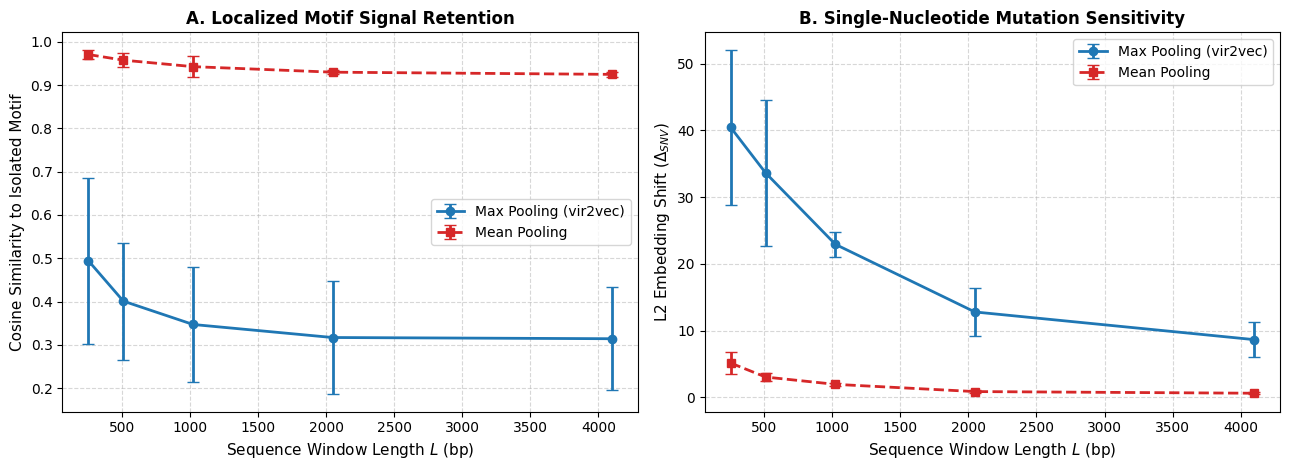

In [9]:
import os
import matplotlib.pyplot as plt

# Aggregate metrics across loci
df_summary = df_results.groupby("window_length").agg({
    "cos_sim_max": ["mean", "std"],
    "cos_sim_mean": ["mean", "std"],
    "l2_shift_max": ["mean", "std"],
    "l2_shift_mean": ["mean", "std"],
})

print("=== HIV-1 HXB2 Pooling Strategy Benchmark ===")
display(df_summary)

# Generate publication figure
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

window_lengths = sorted(df_results["window_length"].unique())

# Panel A: Motif Signal Retention
axes[0].errorbar(
    window_lengths, 
    df_summary[("cos_sim_max", "mean")], 
    yerr=df_summary[("cos_sim_max", "std")],
    fmt='-o', color='#1f77b4', linewidth=2, capsize=4, label="Max Pooling (vir2vec)"
)
axes[0].errorbar(
    window_lengths, 
    df_summary[("cos_sim_mean", "mean")], 
    yerr=df_summary[("cos_sim_mean", "std")],
    fmt='--s', color='#d62728', linewidth=2, capsize=4, label="Mean Pooling"
)
axes[0].set_xlabel("Sequence Window Length $L$ (bp)", fontsize=11)
axes[0].set_ylabel("Cosine Similarity to Isolated Motif", fontsize=11)
axes[0].set_title("A. Localized Motif Signal Retention", fontsize=12, fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend(fontsize=10)

# Panel B: Single-Nucleotide Mutation Sensitivity
axes[1].errorbar(
    window_lengths, 
    df_summary[("l2_shift_max", "mean")], 
    yerr=df_summary[("l2_shift_max", "std")],
    fmt='-o', color='#1f77b4', linewidth=2, capsize=4, label="Max Pooling (vir2vec)"
)
axes[1].errorbar(
    window_lengths, 
    df_summary[("l2_shift_mean", "mean")], 
    yerr=df_summary[("l2_shift_mean", "std")],
    fmt='--s', color='#d62728', linewidth=2, capsize=4, label="Mean Pooling"
)
axes[1].set_xlabel("Sequence Window Length $L$ (bp)", fontsize=11)
axes[1].set_ylabel("L2 Embedding Shift ($\Delta_{SNV}$)", fontsize=11)
axes[1].set_title("B. Single-Nucleotide Mutation Sensitivity", fontsize=12, fontweight="bold")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(fontsize=10)

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/hiv1_pooling_dilution_benchmark.pdf", dpi=300)
plt.show()

=== HIV-1 HXB2 Pooling Strategy Benchmark ===


cos_sim_max           cos_sim_mean           l2_shift_max  \
                     mean       std         mean       std         mean   
window_length                                                             
256              0.494212  0.192171     0.970513  0.011427    40.451384   
512              0.401092  0.135339     0.957538  0.016632    33.638151   
1024             0.347124  0.132956     0.942527  0.023892    22.931173   
2048             0.317019  0.131541     0.929746  0.004209    12.792180   
4096             0.314229  0.118350     0.924678  0.006466     8.647508   

                         l2_shift_mean            
                     std          mean       std  
window_length                                     
256            11.681065      5.126883  1.711084  
512            10.968372      3.034503  0.654317  
1024            1.828588      1.938403  0.250153  
2048            3.627634      0.854325  0.222014  
4096            2.603458      0.605941  0.187130

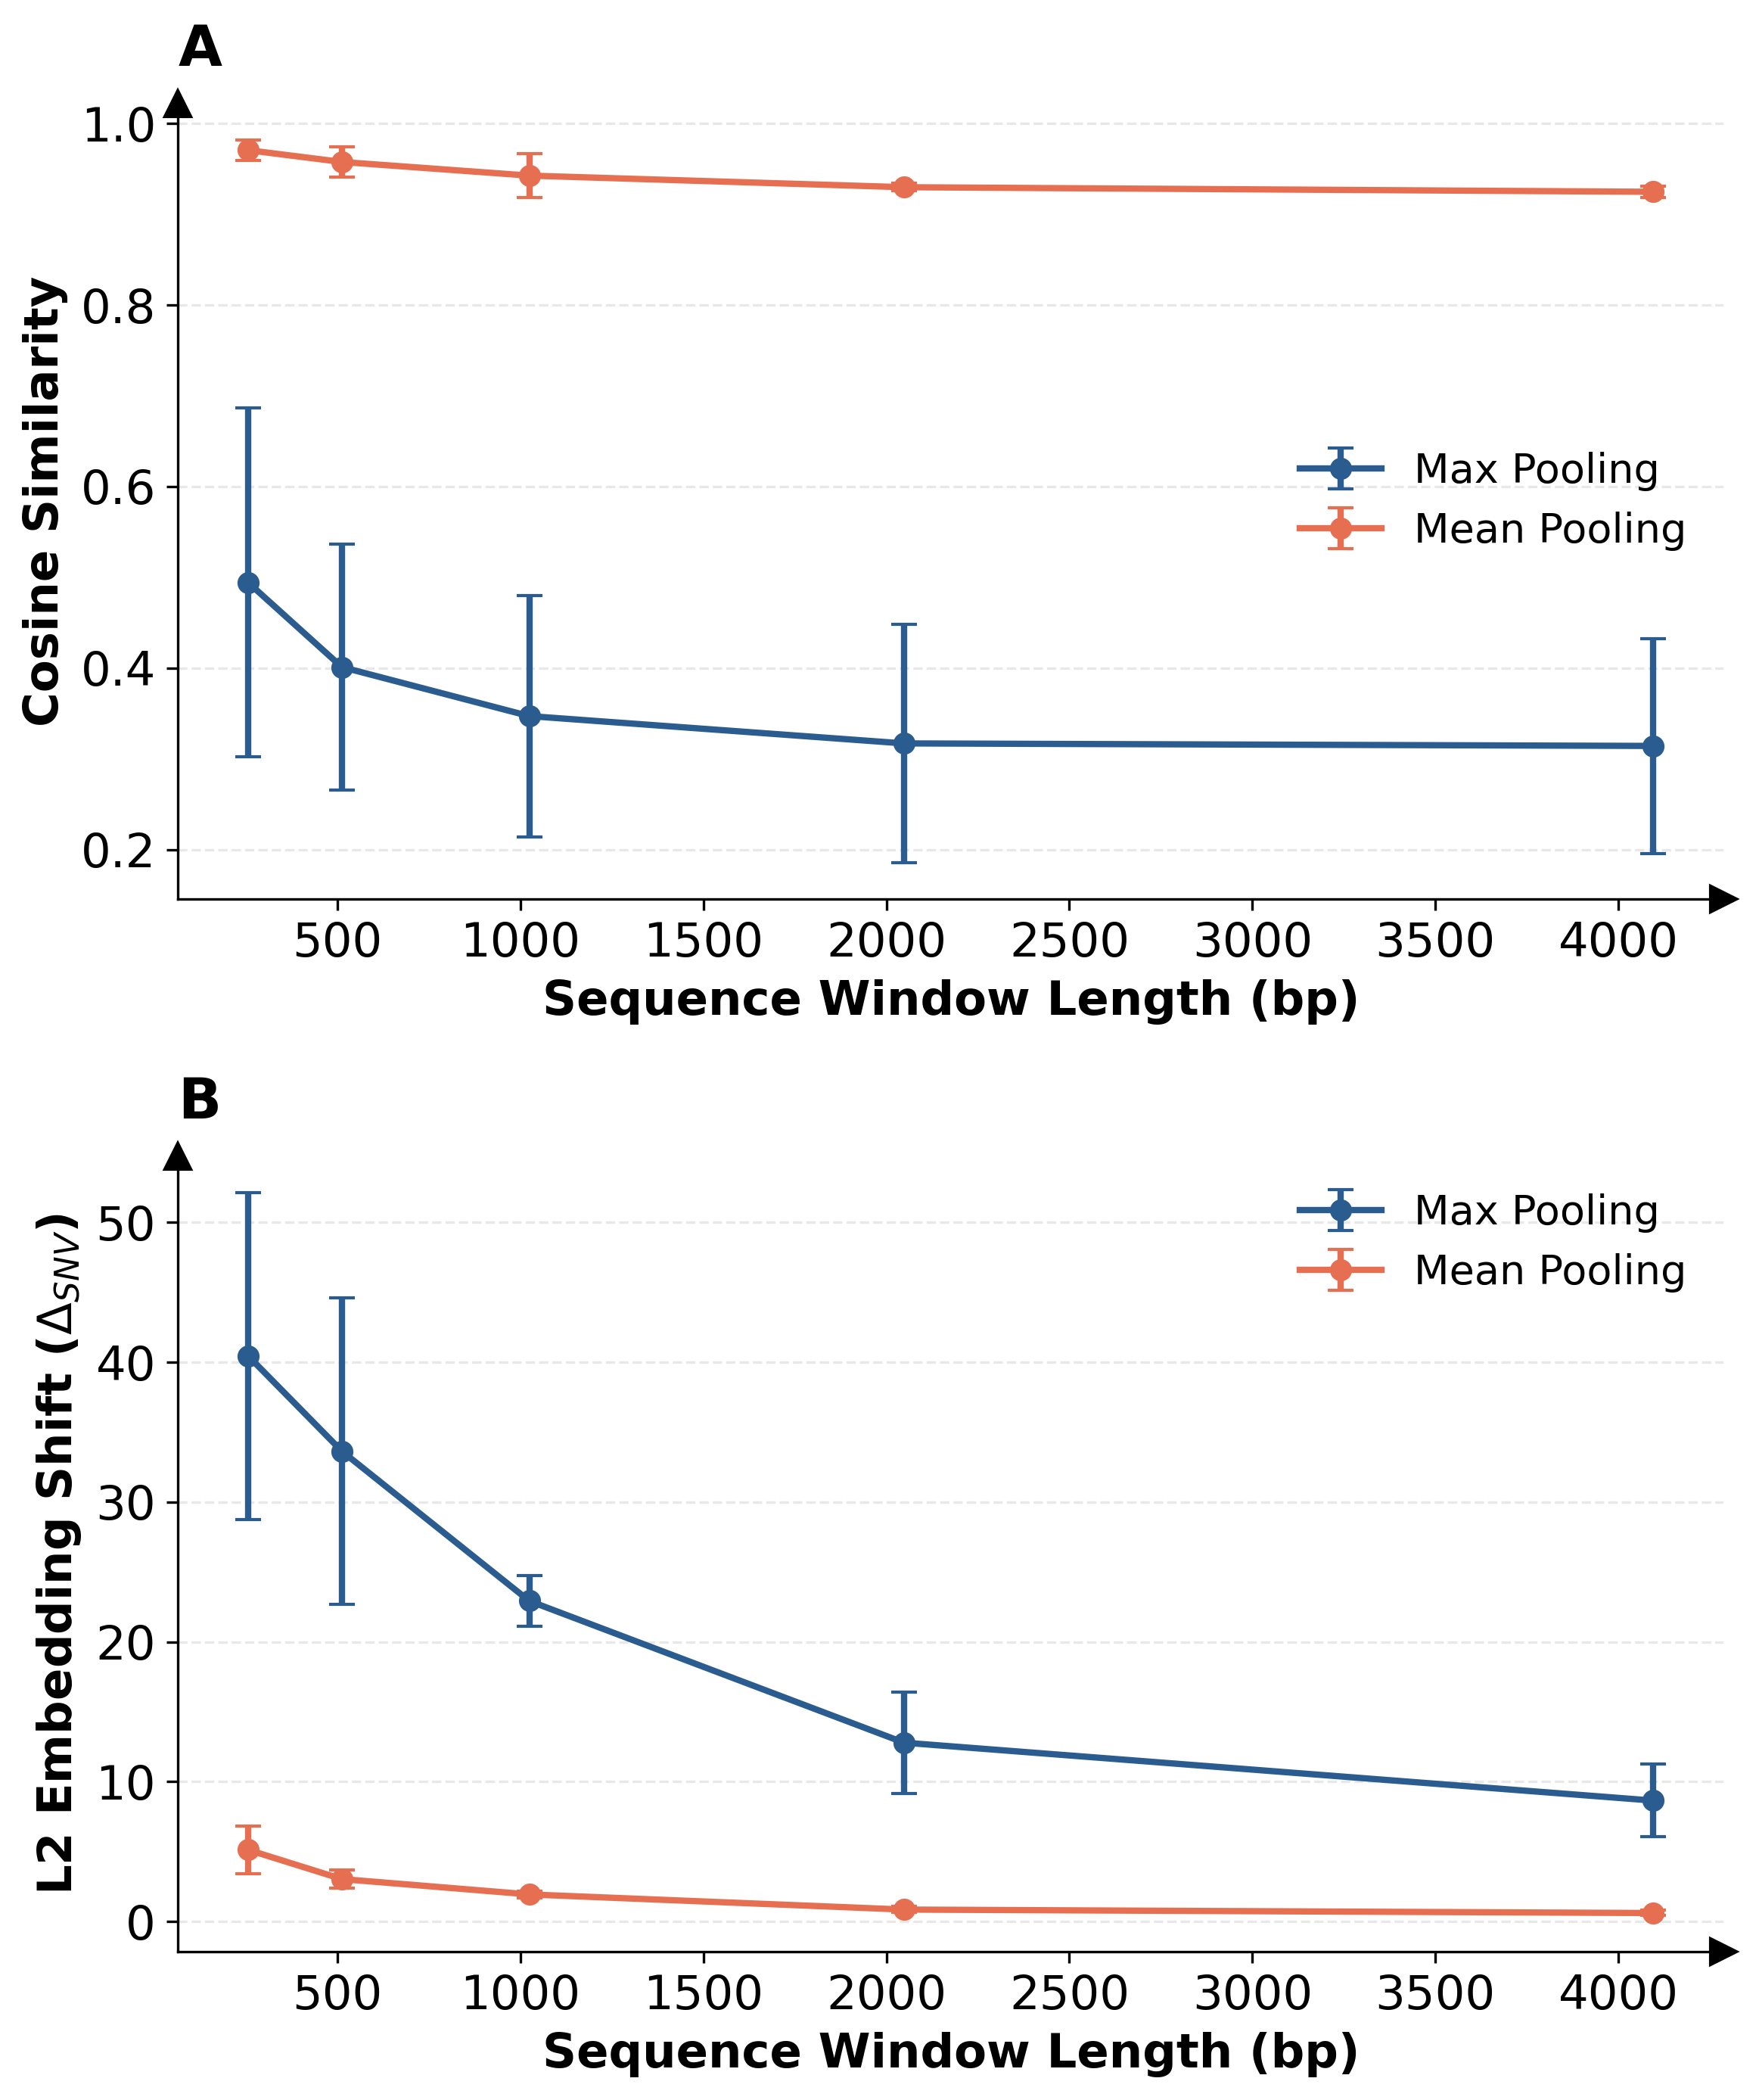

In [13]:
import os
import matplotlib.pyplot as plt

# Publication aesthetics (Nature/Science open axis format)
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 15,
    "axes.labelsize": 15,
    "figure.dpi": 300
})

# Aggregate metrics across loci
df_summary = df_results.groupby("window_length").agg({
    "cos_sim_max": ["mean", "std"],
    "cos_sim_mean": ["mean", "std"],
    "l2_shift_max": ["mean", "std"],
    "l2_shift_mean": ["mean", "std"],
})

print("=== HIV-1 HXB2 Pooling Strategy Benchmark ===")
display(df_summary)

# Generate publication figure (2 rows, 1 column vertical stack)
fig, axes = plt.subplots(2, 1, figsize=(8, 9.5), dpi=300)

window_lengths = sorted(df_results["window_length"].unique())

# Color palette matching reference aesthetic
color_max = "#2b5c8f"   # Deep Blue
color_mean = "#e76f51"  # Coral

# Panel A
axes[0].set_facecolor("white")
axes[0].errorbar(
    window_lengths, 
    df_summary[("cos_sim_max", "mean")], 
    yerr=df_summary[("cos_sim_max", "std")],
    fmt='-o', color=color_max, linewidth=2, capsize=4, label="Max Pooling"
)
axes[0].errorbar(
    window_lengths, 
    df_summary[("cos_sim_mean", "mean")], 
    yerr=df_summary[("cos_sim_mean", "std")],
    fmt='-o', color=color_mean, linewidth=2, capsize=4, label="Mean Pooling"
)
axes[0].set_xlabel("Sequence Window Length (bp)", fontweight="bold")
axes[0].set_ylabel("Cosine Similarity", fontweight="bold")
axes[0].set_title("A", fontweight="bold", loc="left", pad=12)
axes[0].legend(fontsize=13, frameon=False)

# Panel B
axes[1].set_facecolor("white")
axes[1].errorbar(
    window_lengths, 
    df_summary[("l2_shift_max", "mean")], 
    yerr=df_summary[("l2_shift_max", "std")],
    fmt='-o', color=color_max, linewidth=2, capsize=4, label="Max Pooling"
)
axes[1].errorbar(
    window_lengths, 
    df_summary[("l2_shift_mean", "mean")], 
    yerr=df_summary[("l2_shift_mean", "std")],
    fmt='-o', color=color_mean, linewidth=2, capsize=4, label="Mean Pooling"
)
axes[1].set_xlabel("Sequence Window Length (bp)", fontweight="bold")
axes[1].set_ylabel("L2 Embedding Shift ($\Delta_{SNV}$)", fontweight="bold")
axes[1].set_title("B", fontweight="bold", loc="left", pad=12)
axes[1].legend(fontsize=13, frameon=False)

# Open axis styling, arrowheads, and soft horizontal grid lines
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    # Soft horizontal dashed grid lines behind points
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, color="#d3d3d3")
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)
    
    # Arrowheads directly at axis tips using axis fraction coordinates
    ax.plot(1.0, 0.0, marker=">", color="black", transform=ax.transAxes, clip_on=False, markersize=8)
    ax.plot(0.0, 1.0, marker="^", color="black", transform=ax.transAxes, clip_on=False, markersize=8)

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/hiv1_pooling_dilution_benchmark.png", dpi=300, bbox_inches="tight")
plt.show()